# Review 1 — K-Nearest Neighbors Regressor

**Track:** Regression

**Dataset:** Wine Quality White

This notebook implements the required regression algorithm using the same dataset, preprocessing policy, and 80:20 held-out split used by the other regression notebooks.

## 1. Imports and Project Paths

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "Review-1" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from preprocessing import load_wine_dataset, clean_wine_dataset, split_data, make_preprocessor, make_polynomial_preprocessor, regression_metrics, RANDOM_STATE

DATA_PATH = PROJECT_ROOT / "data" / "winequality-white.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## 2. Dataset Audit and EDA

In [2]:
df_raw = load_wine_dataset(DATA_PATH)
print("Raw shape:", df_raw.shape)
print("Duplicate rows:", df_raw.duplicated().sum())
display(df_raw.head())
display(df_raw.dtypes.to_frame("dtype"))
display(df_raw.isna().sum().to_frame("missing_count"))


Raw shape: (4898, 12)
Duplicate rows: 937


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


,dtype
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


,missing_count
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


### Engineered feature: `total_acidity`

The project creates `total_acidity` as the sum of **fixed acidity** and **volatile acidity**. This provides a simple combined acidity measure for the regression models. The feature is created before the train/test split so every regression model uses the same engineered dataset.

In [3]:
df = clean_wine_dataset(df_raw)
print("Original rows:", len(df_raw))
print("Duplicate rows removed:", int(df_raw.duplicated().sum()))
print("Rows after duplicate removal:", len(df))
print("Engineered feature `total_acidity` = fixed acidity + volatile acidity.")
display(df[["fixed acidity", "volatile acidity", "total_acidity", "quality"]].head())
print("Quality distribution:")
display(df["quality"].value_counts().sort_index().to_frame("count"))


Original rows: 4898
Duplicate rows removed: 937
Rows after duplicate removal: 3961
Engineered feature `total_acidity` = fixed acidity + volatile acidity.


,fixed acidity,volatile acidity,total_acidity,quality
0,7.0,0.27,7.27,6
1,6.3,0.30,6.60,6
2,8.1,0.28,8.38,6
3,7.2,0.23,7.43,6
4,6.2,0.32,6.52,6


Quality distribution:


,count
quality,
3,20
4,153
5,1175
6,1788
7,689
8,131
9,5


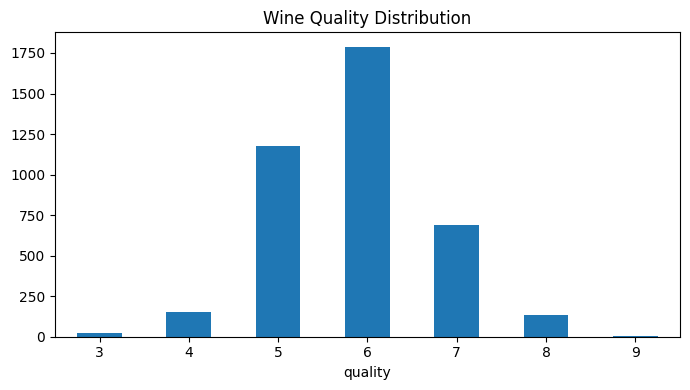

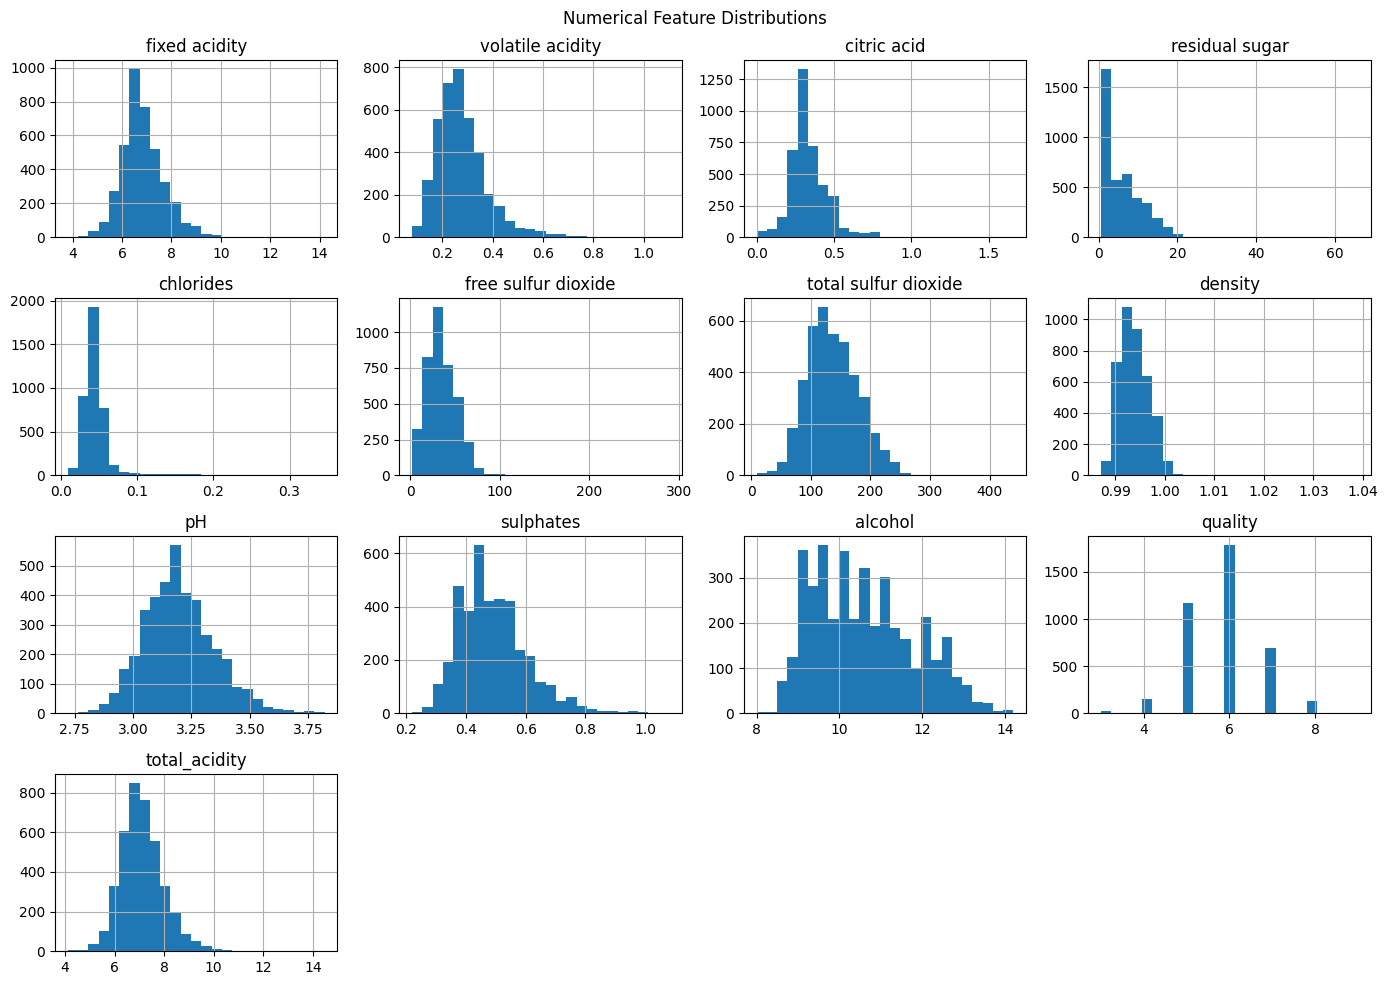

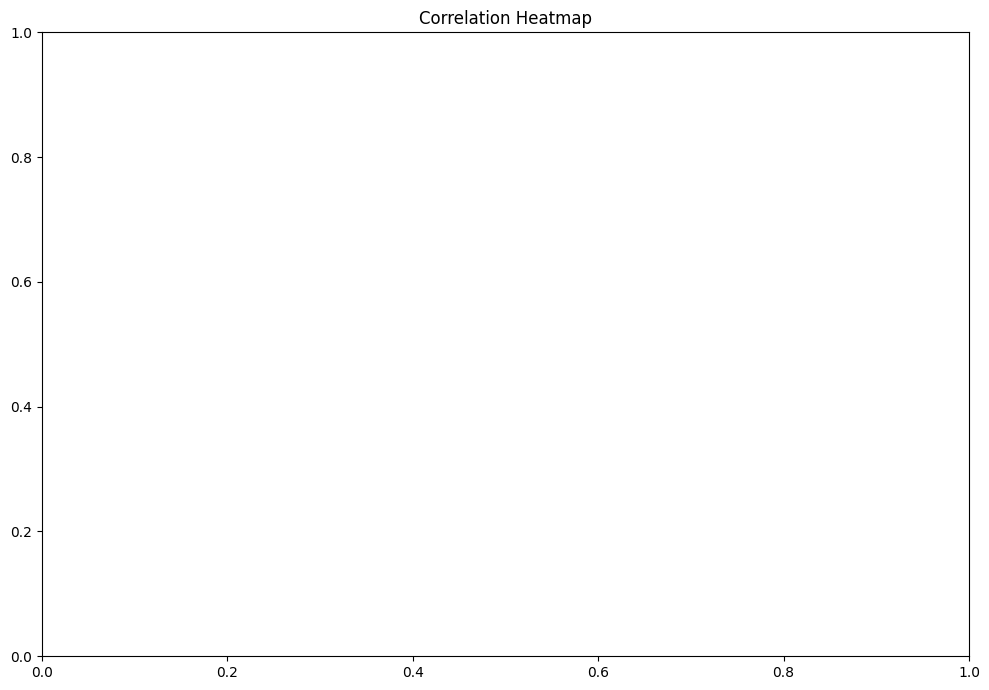

In [4]:
fig, ax = plt.subplots(figsize=(7,4))
df["quality"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_title("Wine Quality Distribution")
plt.tight_layout(); plt.show()

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(14,10), bins=25)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)
ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index))); ax.set_yticklabels(corr.index)
plt.title("Correlation Heatmap")
plt.tight_layout(); plt.show()


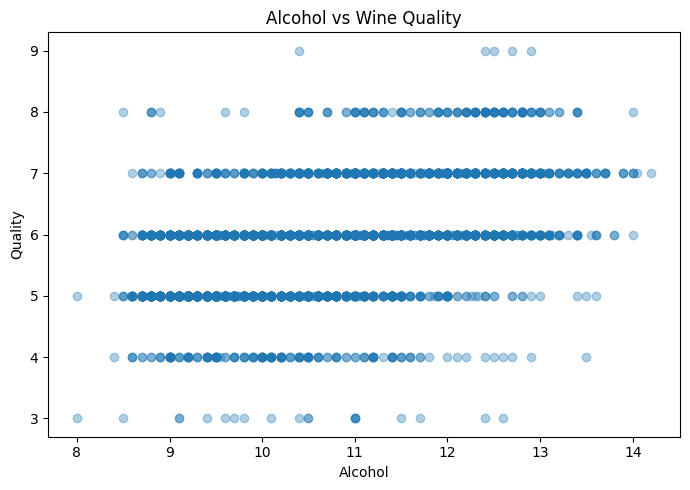

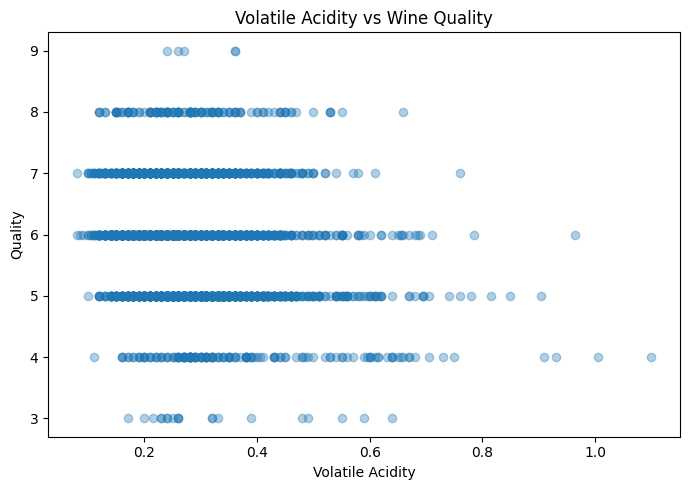

In [5]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(df["alcohol"], df["quality"], alpha=0.35)
ax.set_title("Alcohol vs Wine Quality")
ax.set_xlabel("Alcohol")
ax.set_ylabel("Quality")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(df["volatile acidity"], df["quality"], alpha=0.35)
ax.set_title("Volatile Acidity vs Wine Quality")
ax.set_xlabel("Volatile Acidity")
ax.set_ylabel("Quality")
plt.tight_layout(); plt.show()


### Student Observation — Feature vs Target

**Alcohol vs Quality:** Write 1–2 sentences here based on the actual plot.

**Volatile Acidity vs Quality:** Write 1–2 sentences here based on the actual plot.

### Outlier analysis

In [6]:
X_for_audit = df.drop(columns=["quality"])
q1 = X_for_audit.quantile(0.25)
q3 = X_for_audit.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_counts = ((X_for_audit < lower) | (X_for_audit > upper)).sum().sort_values(ascending=False)
display(outlier_counts.to_frame("IQR_potential_outlier_count"))
print("Total row-feature outlier flags:", int(((X_for_audit < lower) | (X_for_audit > upper)).sum().sum()))


,IQR_potential_outlier_count
citric acid,223
chlorides,178
volatile acidity,133
fixed acidity,106
total_acidity,98
sulphates,96
pH,46
free sulfur dioxide,44
residual sugar,16
total sulfur dioxide,14


Total row-feature outlier flags: 960


### Outlier decision

The IQR method is used to identify **potential** outliers; it does not prove that the observations are erroneous. The potential outliers are retained because extreme chemical measurements can be plausible observations in a real wine dataset, and deleting them blindly could remove legitimate variation. No outlier thresholds are fitted into the predictive pipeline, so no test-set-derived treatment is applied.

**Student Observation:** Write 1–2 sentences here about the outlier counts and whether the retained values appear plausible based on the dataset context.

## 3. Train/Test Split and Preprocessing

In [7]:
X = df.drop(columns=["quality"])
y = df["quality"]
X_train, X_test, y_train, y_test = split_data(X, y)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (3168, 12) Test: (793, 12)


In [8]:
preprocessor = make_preprocessor(X_train, scale_numeric=True)


## 4. Model Training

In [9]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=7)
pipe = Pipeline([("preprocess", preprocessor), ("model", model)])


## Evaluation

In [10]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
metrics = regression_metrics(y_test, y_pred)
print(metrics)
result = {"model": 'K-Nearest Neighbors Regressor', **metrics}
pd.DataFrame([result]).to_csv(RESULTS_DIR / '10_knn_regressor.csv', index=False)
joblib.dump(pipe, MODELS_DIR / '10_knn_regressor.joblib')
display(pd.DataFrame([result]))


{'R2': 0.27773199418908534, 'RMSE': 0.7696437113811418, 'MAE': 0.5935867411277247}


,model,R2,RMSE,MAE
0,K-Nearest Neighbors Regressor,0.277732,0.769644,0.593587


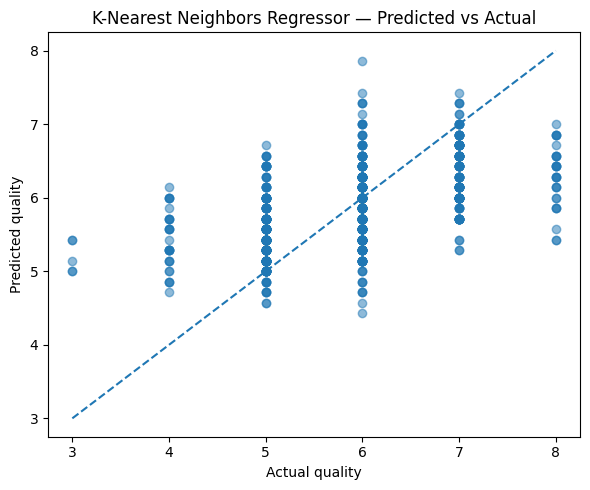

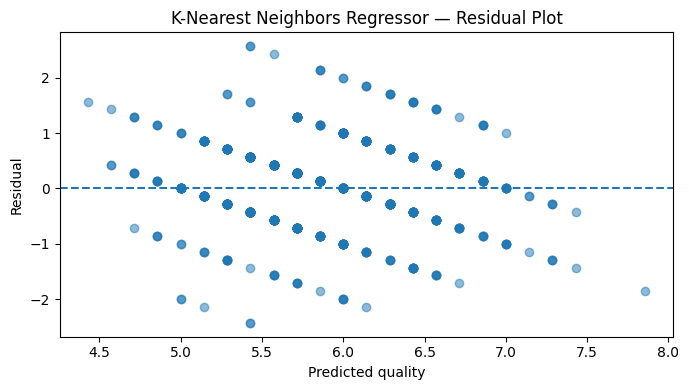

In [11]:
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(y_test, y_pred, alpha=0.5)
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax.plot([lo,hi],[lo,hi], linestyle="--")
ax.set_xlabel("Actual quality"); ax.set_ylabel("Predicted quality")
ax.set_title(f"{'K-Nearest Neighbors Regressor'} — Predicted vs Actual")
plt.tight_layout(); plt.show()

residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(y_pred, residuals, alpha=0.5)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted quality"); ax.set_ylabel("Residual")
ax.set_title(f"{'K-Nearest Neighbors Regressor'} — Residual Plot")
plt.tight_layout(); plt.show()


Numeric features are standardized because KNN uses distances.